In [7]:
# List unique battery packs for each chassis
unique_packs_per_chassis = df.groupby('CHASSI_NO')['BATTERY_PACK'].unique()
display(unique_packs_per_chassis)

CHASSI_NO
1       [2, 4, 1, 6, 3, 5]
2       [5, 3, 1, 6, 4, 2]
3    [1, 6, 4, 5, 3, 2, 0]
4       [3, 4, 5, 1, 6, 2]
Name: BATTERY_PACK, dtype: object

In [2]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

In [4]:
# Load the data
df = pd.read_csv('battery_data.csv')
df.head()

,CHASSI_NO,HOUR_TIMESTAMP,BATTERY_PACK,ACCUMULATED_DISCHARGED_ENERGY_WH,LAT,LNG
0,1,2025-09-01 05:00:00,2,19400.0,59.3293,18.0686
1,1,2025-09-01 05:00:00,4,20100.0,59.3293,18.0686
2,1,2025-09-01 05:00:00,1,18900.0,59.3293,18.0686
3,1,2025-09-01 05:00:00,6,19500.0,59.3293,18.0686
4,1,2025-09-01 05:00:00,3,19700.0,59.3293,18.0686


In [5]:
# Data info and summary
print('--- Data Info ---')
df.info()
print('\n--- Data Description ---')
display(df.describe())
print('\n--- Null Values ---')
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7458 entries, 0 to 7457
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CHASSI_NO                         7458 non-null   int64  
 1   HOUR_TIMESTAMP                    7458 non-null   str    
 2   BATTERY_PACK                      7458 non-null   int64  
 3   ACCUMULATED_DISCHARGED_ENERGY_WH  7458 non-null   float64
 4   LAT                               7458 non-null   float64
 5   LNG                               7458 non-null   float64
dtypes: float64(3), int64(2), str(1)
memory usage: 349.7 KB

--- Data Description ---


,CHASSI_NO,BATTERY_PACK,ACCUMULATED_DISCHARGED_ENERGY_WH,LAT,LNG
count,7458.000000,7458.000000,7.458000e+03,7458.000000,7458.000000
mean,2.410298,3.489273,1.374898e+07,55.843777,14.362798
std,1.111251,1.717302,9.185715e+06,3.393470,4.411745
min,1.000000,0.000000,1.890000e+04,52.367600,4.904100
25%,2.000000,2.000000,1.056540e+07,52.520000,13.405000
50%,2.000000,3.000000,1.358340e+07,52.520000,13.405000
75%,4.000000,5.000000,2.394930e+07,59.195500,17.625000
max,4.000000,6.000000,2.567540e+07,59.329300,18.068600



--- Null Values ---
CHASSI_NO                           0
HOUR_TIMESTAMP                      0
BATTERY_PACK                        0
ACCUMULATED_DISCHARGED_ENERGY_WH    0
LAT                                 0
LNG                                 0
dtype: int64


In [6]:
print(f"Unique vehicles: {df['CHASSI_NO'].nunique()}")
print(f"Unique battery packs: {df['BATTERY_PACK'].nunique()}")

Unique vehicles: 4
Unique battery packs: 7


In [8]:
# Unique locations
unique_locations = df[['LAT', 'LNG']].drop_duplicates()
print('Unique locations:')
display(unique_locations)

Unique locations:


,LAT,LNG
0,59.3293,18.0686
1812,52.5200,13.4050
4476,52.3676,4.9041
5568,59.1955,17.6250


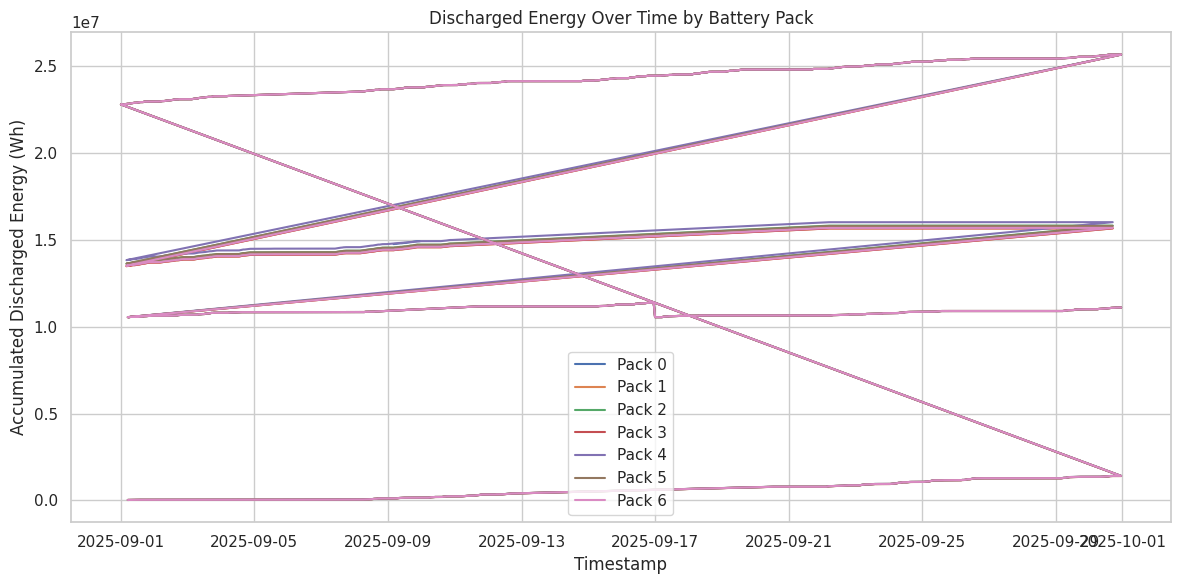

In [24]:
plt.figure(figsize=(12,6))
for pack in sorted(df['BATTERY_PACK'].unique()):
    pack_df = df[df['BATTERY_PACK'] == pack]
    plt.plot(pd.to_datetime(pack_df['HOUR_TIMESTAMP']), pack_df['ACCUMULATED_DISCHARGED_ENERGY_WH'], label=f'Pack {pack}')
plt.xlabel('Timestamp')
plt.ylabel('Accumulated Discharged Energy (Wh)')
plt.title('Discharged Energy Over Time by Battery Pack')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
print('--- Sudden Jumps in Energy ---')
threshold = 1000  # Wh
for pack in sorted(df['BATTERY_PACK'].unique()):
    pack_df = df[df['BATTERY_PACK'] == pack].sort_values('HOUR_TIMESTAMP')
    diffs = pack_df['ACCUMULATED_DISCHARGED_ENERGY_WH'].diff()
    jumps = diffs[diffs > threshold]
    if not jumps.empty:
        print(f'Pack {pack} jumps:')
        print(jumps)

--- Sudden Jumps in Energy ---
Pack 0 jumps:
5248    12300.0
5252     3300.0
5260    12600.0
5262    10300.0
5270     8100.0
5281    13000.0
5290     7300.0
5293     3000.0
5302    14200.0
5306    14800.0
5310    12500.0
5320     5500.0
5325    10900.0
5330    19300.0
5335    11600.0
5343    11600.0
Name: ACCUMULATED_DISCHARGED_ENERGY_WH, dtype: float64
Pack 1 jumps:
1831       14100.0
1841       11000.0
1846    22824500.0
1852    22824800.0
4488     2961700.0
           ...    
7438     9703500.0
4461    24274600.0
4467    14571200.0
7447     9703900.0
4471    24274900.0
Name: ACCUMULATED_DISCHARGED_ENERGY_WH, Length: 576, dtype: float64
Pack 2 jumps:
1834       14100.0
1840       11000.0
1847    22824000.0
1849    22824100.0
4492     3098500.0
           ...    
7434     9698600.0
4462    24269700.0
4466    14571200.0
7446     9699000.0
4475    24270000.0
Name: ACCUMULATED_DISCHARGED_ENERGY_WH, Length: 576, dtype: float64
Pack 3 jumps:
1830       14100.0
1836       11000.0
1842    22

In [26]:
print('--- Repeated Energy Values ---')
for pack in sorted(df['BATTERY_PACK'].unique()):
    pack_df = df[df['BATTERY_PACK'] == pack].sort_values('HOUR_TIMESTAMP')
    repeats = pack_df['ACCUMULATED_DISCHARGED_ENERGY_WH'].value_counts()
    repeated = repeats[repeats > 1]
    if not repeated.empty:
        print(f'Pack {pack} repeated values:')
        print(repeated)

--- Repeated Energy Values ---
Pack 0 repeated values:
ACCUMULATED_DISCHARGED_ENERGY_WH
14930100.0    3
Name: count, dtype: int64
Pack 1 repeated values:
ACCUMULATED_DISCHARGED_ENERGY_WH
11169500.0    9
10648900.0    9
10840200.0    7
10904700.0    7
14137700.0    5
             ..
1269400.0     2
1269900.0     2
1348300.0     2
1356400.0     2
1399800.0     2
Name: count, Length: 88, dtype: int64
Pack 2 repeated values:
ACCUMULATED_DISCHARGED_ENERGY_WH
11169500.0    9
10648900.0    9
10840200.0    7
10904700.0    7
13835200.0    6
             ..
1274000.0     2
1274100.0     2
1353100.0     2
1361200.0     2
1404700.0     2
Name: count, Length: 91, dtype: int64
Pack 3 repeated values:
ACCUMULATED_DISCHARGED_ENERGY_WH
11169500.0    9
10648900.0    9
10840200.0    7
10904700.0    7
13696200.0    6
             ..
1269400.0     2
1269900.0     2
1270000.0     2
1356300.0     2
1399800.0     2
Name: count, Length: 90, dtype: int64
Pack 4 repeated values:
ACCUMULATED_DISCHARGED_ENERGY_WH


## PLot for Total Discharged Energy Across All Packs

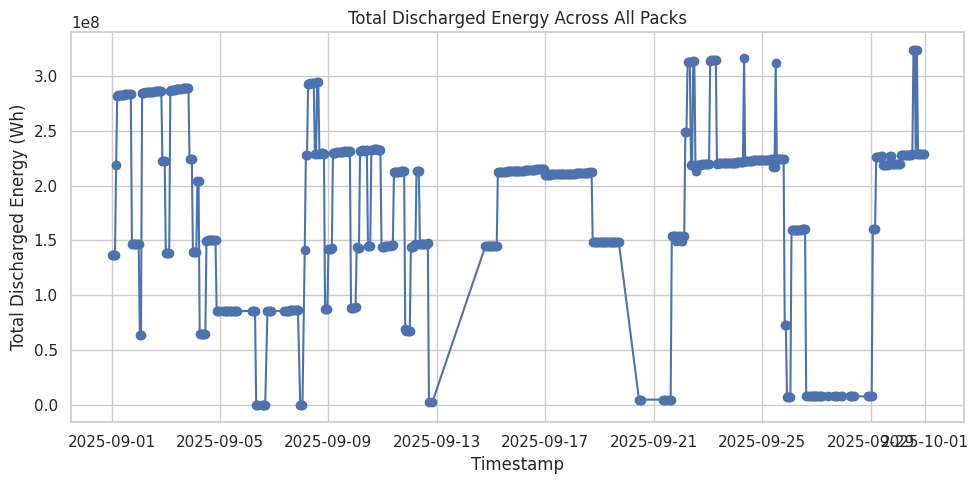

,HOUR_TIMESTAMP,ACCUMULATED_DISCHARGED_ENERGY_WH
0,2025-09-01 00:00:00,136839600.0
1,2025-09-01 01:00:00,136840200.0
2,2025-09-01 02:00:00,136840800.0
3,2025-09-01 03:00:00,136925400.0
4,2025-09-01 04:00:00,218579300.0
...,...,...
567,2025-09-30 19:00:00,229058500.0
568,2025-09-30 20:00:00,229086100.0
569,2025-09-30 21:00:00,229090200.0
570,2025-09-30 22:00:00,229094400.0


In [27]:
agg = df.groupby(['HOUR_TIMESTAMP'])['ACCUMULATED_DISCHARGED_ENERGY_WH'].sum().reset_index()
plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(agg['HOUR_TIMESTAMP']), agg['ACCUMULATED_DISCHARGED_ENERGY_WH'], marker='o')
plt.xlabel('Timestamp')
plt.ylabel('Total Discharged Energy (Wh)')
plt.title('Total Discharged Energy Across All Packs')
plt.tight_layout()
plt.show()
display(agg)

# Individual Chassis Analysis

In [9]:
# 1. Check unique chassis numbers and their distribution
chassis_counts = df['CHASSI_NO'].value_counts()
print(f"Unique chassis numbers: {df['CHASSI_NO'].nunique()}")
display(chassis_counts)

Unique chassis numbers: 4


CHASSI_NO
2    2664
4    1890
1    1812
3    1092
Name: count, dtype: int64

## PLot Discharged Energy Over Time by Chassis 

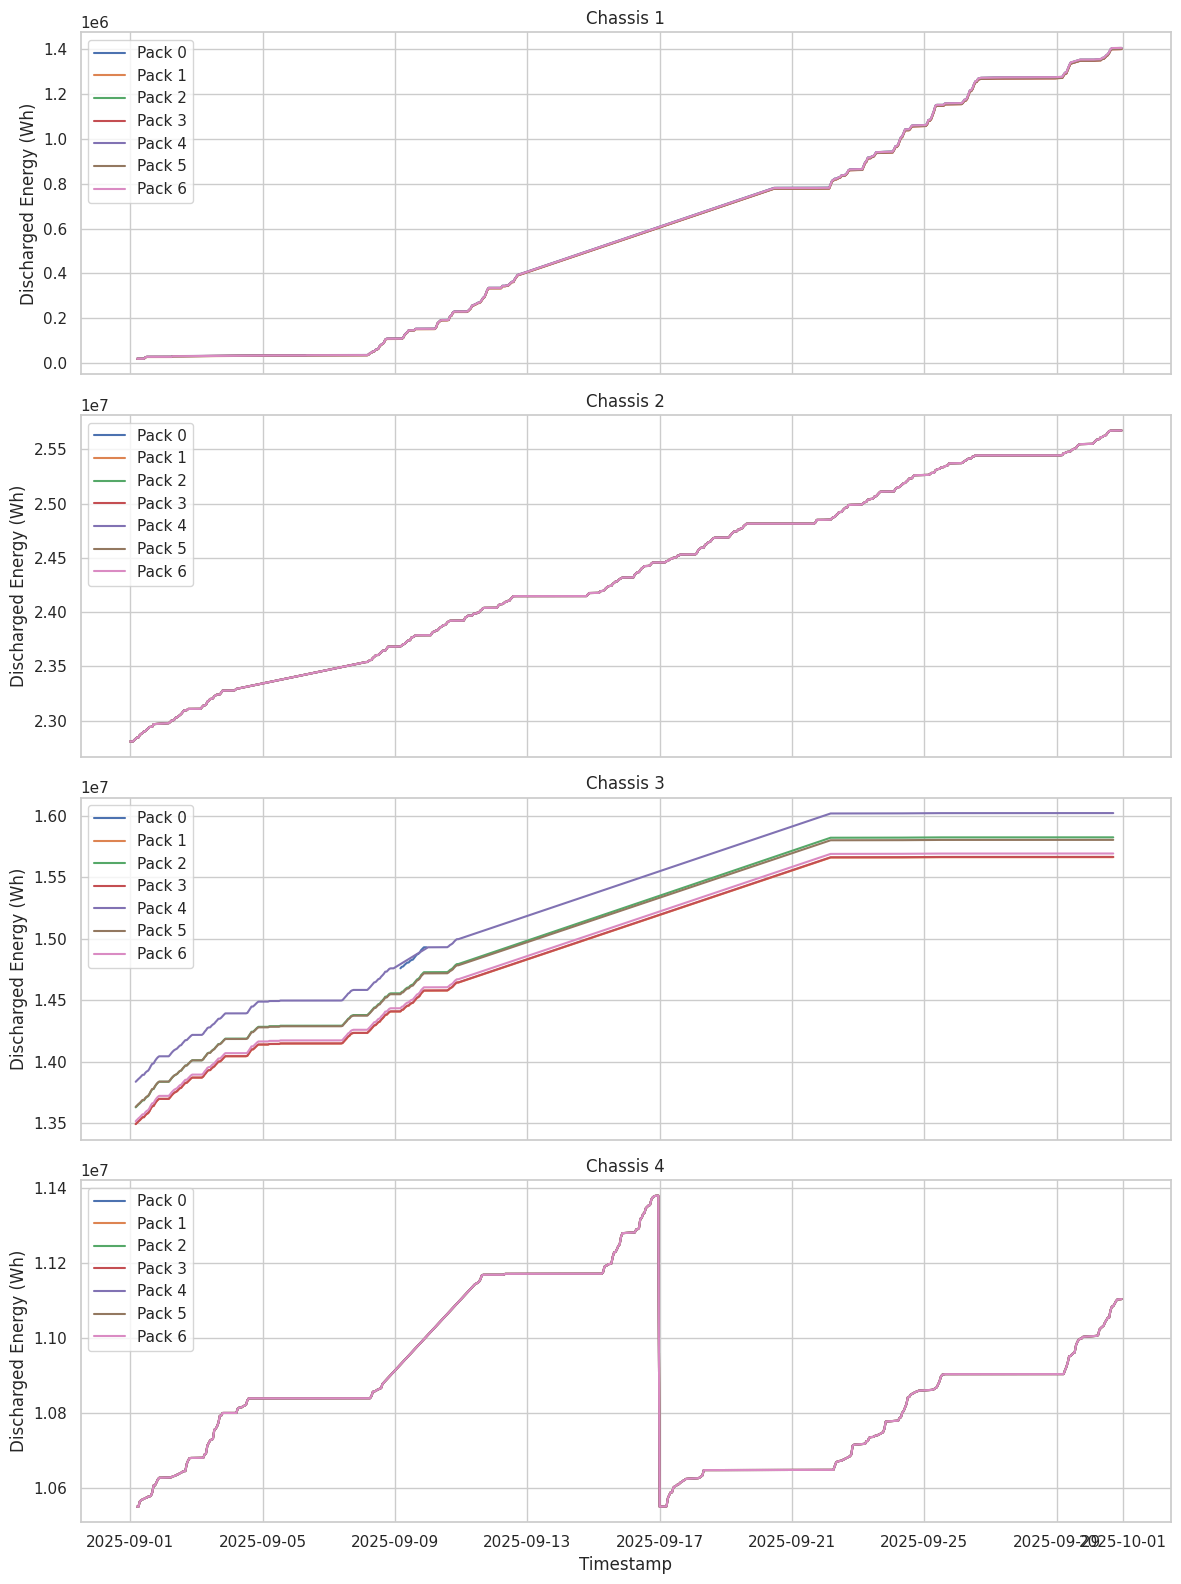

In [29]:
# 2. Visualize discharged energy for each chassis and pack
chassis_list = df['CHASSI_NO'].unique()
fig, axes = plt.subplots(len(chassis_list), 1, figsize=(12, 4*len(chassis_list)), sharex=True)
if len(chassis_list) == 1:
    axes = [axes]
for i, chassis in enumerate(sorted(chassis_list)):
    ax = axes[i]
    for pack in sorted(df['BATTERY_PACK'].unique()):
        sub = df[(df['CHASSI_NO'] == chassis) & (df['BATTERY_PACK'] == pack)]
        ax.plot(pd.to_datetime(sub['HOUR_TIMESTAMP']), sub['ACCUMULATED_DISCHARGED_ENERGY_WH'], label=f'Pack {pack}')
    ax.set_title(f'Chassis {chassis}')
    ax.set_ylabel('Discharged Energy (Wh)')
    ax.legend()
plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()

## Check for sudden jumps and repeated values for each chassis and battery pack

In [30]:
# 3. Data quality checks per chassis and pack
print('--- Sudden Jumps in Energy by Chassis and Pack ---')
threshold = 1000  # Wh
for chassis in sorted(df['CHASSI_NO'].unique()):
    for pack in sorted(df['BATTERY_PACK'].unique()):
        sub = df[(df['CHASSI_NO'] == chassis) & (df['BATTERY_PACK'] == pack)].sort_values('HOUR_TIMESTAMP')
        diffs = sub['ACCUMULATED_DISCHARGED_ENERGY_WH'].diff()
        jumps = diffs[diffs > threshold]
        if not jumps.empty:
            print(f'Chassis {chassis}, Pack {pack} jumps:')
            print(jumps)

print('\n--- Repeated Energy Values by Chassis and Pack ---')
for chassis in sorted(df['CHASSI_NO'].unique()):
    for pack in sorted(df['BATTERY_PACK'].unique()):
        sub = df[(df['CHASSI_NO'] == chassis) & (df['BATTERY_PACK'] == pack)].sort_values('HOUR_TIMESTAMP')
        repeats = sub['ACCUMULATED_DISCHARGED_ENERGY_WH'].value_counts()
        repeated = repeats[repeats > 1]
        if not repeated.empty:
            print(f'Chassis {chassis}, Pack {pack} repeated values:')
            print(repeated)

--- Sudden Jumps in Energy by Chassis and Pack ---
Chassis 1, Pack 1 jumps:
37       5900.0
44       2300.0
71       2800.0
105      3200.0
230      2700.0
         ...   
1740     6700.0
1749     4300.0
1752     8900.0
1759    12700.0
1765     5400.0
Name: ACCUMULATED_DISCHARGED_ENERGY_WH, Length: 120, dtype: float64
Chassis 1, Pack 2 jumps:
39       5900.0
47       2300.0
66       2800.0
107      3300.0
232      2700.0
         ...   
1745     6800.0
1751     4300.0
1753     8900.0
1761    12700.0
1764     5500.0
Name: ACCUMULATED_DISCHARGED_ENERGY_WH, Length: 120, dtype: float64
Chassis 1, Pack 3 jumps:
41       5900.0
46       2300.0
67       2800.0
103      3300.0
231      2700.0
         ...   
1741     6700.0
1748     4300.0
1756     8900.0
1760    12700.0
1769     5500.0
Name: ACCUMULATED_DISCHARGED_ENERGY_WH, Length: 120, dtype: float64
Chassis 1, Pack 4 jumps:
40       5800.0
45       2400.0
68       2800.0
104      3200.0
228      2600.0
         ...   
1743     6800.0
1746 

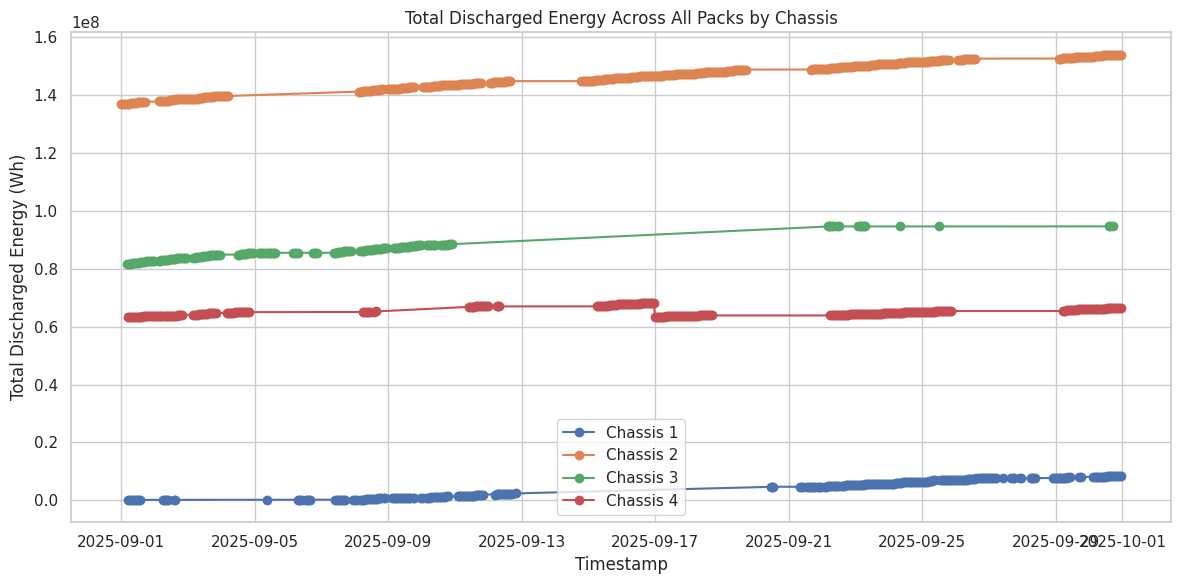

,CHASSI_NO,HOUR_TIMESTAMP,ACCUMULATED_DISCHARGED_ENERGY_WH
0,1,2025-09-01 05:00:00,116900.0
1,1,2025-09-01 06:00:00,117500.0
2,1,2025-09-01 07:00:00,117700.0
3,1,2025-09-01 08:00:00,117800.0
4,1,2025-09-01 09:00:00,118000.0
...,...,...,...
1238,4,2025-09-30 19:00:00,66596400.0
1239,4,2025-09-30 20:00:00,66622200.0
1240,4,2025-09-30 21:00:00,66624000.0
1241,4,2025-09-30 22:00:00,66625800.0


In [31]:
# 4. Aggregated reporting by chassis
grouped = df.groupby(['CHASSI_NO', 'HOUR_TIMESTAMP'])['ACCUMULATED_DISCHARGED_ENERGY_WH'].sum().reset_index()
plt.figure(figsize=(12,6))
for chassis in sorted(df['CHASSI_NO'].unique()):
    sub = grouped[grouped['CHASSI_NO'] == chassis]
    plt.plot(pd.to_datetime(sub['HOUR_TIMESTAMP']), sub['ACCUMULATED_DISCHARGED_ENERGY_WH'], marker='o', label=f'Chassis {chassis}')
plt.xlabel('Timestamp')
plt.ylabel('Total Discharged Energy (Wh)')
plt.title('Total Discharged Energy Across All Packs by Chassis')
plt.legend()
plt.tight_layout()
plt.show()
display(grouped)